In [16]:
import sys
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

BASE = Path("/Users/jakobwerkgarner/code/mt_dsnow")
sys.path.insert(0, str(BASE))
from plot_style import apply_style, C, ALPHA, LS, FIG
apply_style()
warnings.filterwarnings("ignore")

NC_PATH = BASE / "model_diff/layerwise_data/combined_layerwise_default_Mag25.nc"
OUT_DIR = BASE / "model_diff/HS_and_SWE/figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load ───────────────────────────────────────────────────────────────────────
ds       = xr.open_dataset(NC_PATH)
stations = np.array([str(s) for s in ds["station"].values])
ds       = ds.sel(station=stations[[s not in {"Weisfluh_Joch"} for s in stations]])
stn      = [str(s) for s in ds["station"].values]
N_STA    = len(stn)
t_full   = pd.DatetimeIndex(ds["time"].values)

# ── Shared constants ───────────────────────────────────────────────────────────
N_DOYS       = 365
MONTH_TICKS  = [1, 31, 62, 92, 123, 153, 184, 214, 245, 275, 306, 336]
MONTH_LABELS = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]
doy_ax       = np.arange(1, N_DOYS + 1)
YR_COLORS    = [C.MAGNUSSON, C.SNOWPACK, C.WINKLER, C.HS, "#555555", "#AAAAAA"]

# Hydro-year and hydro-doy for the full time axis
hyr_full  = np.where(t_full.month >= 9, t_full.year, t_full.year - 1)
hdoy_full = np.array([
    (t - pd.Timestamp(int(yr), 9, 1)).days + 1
    for t, yr in zip(t_full, hyr_full)
], dtype=int)
SEASONS_HY = np.unique(hyr_full)

# ── 1.  Cumulative new-layer height ───────────────────────────────────────────
def daily_new_layer_height(h_arr):
    h_nz     = np.where(np.isnan(h_arr), 0.0, h_arr)
    prev      = np.zeros_like(h_nz)
    prev[1:] = h_nz[:-1]
    return np.where((h_nz > 0) & (prev == 0), h_arr, 0.0).sum(axis=2)

def season_doy_grid(daily_arr):
    grid = np.zeros((len(SEASONS_HY), N_DOYS, N_STA))
    for yi, yr in enumerate(SEASONS_HY):
        mask = hyr_full == yr
        doys = hdoy_full[mask]
        vals = daily_arr[mask]
        for i, d in enumerate(doys):
            if 1 <= d <= N_DOYS:
                grid[yi, d - 1] += vals[i]
    return grid

def pooled_pct(arr):
    flat = arr.transpose(1, 0, 2).reshape(N_DOYS, -1)
    return (np.nanpercentile(flat, 25, axis=1),
            np.nanpercentile(flat, 50, axis=1),
            np.nanpercentile(flat, 75, axis=1))

cum_ds = np.cumsum(season_doy_grid(daily_new_layer_height(ds["dsnow_h"].values)),  axis=1)
cum_h2 = np.cumsum(season_doy_grid(daily_new_layer_height(ds["hs2swe_h"].values)), axis=1)

ds_q25, ds_med, ds_q75 = pooled_pct(cum_ds)
h2_q25, h2_med, h2_q75 = pooled_pct(cum_h2)

# ── 2.  Cumulative SWE gain / loss ────────────────────────────────────────────
t_dt    = t_full[1:]
d_diff  = np.diff(ds["dsnow_swe_total"].values,  axis=0)
h_diff  = np.diff(ds["hs2swe_swe_total"].values, axis=0)

ti_dt   = pd.DatetimeIndex(t_dt)
hyr_dt  = np.where(ti_dt.month >= 9, ti_dt.year, ti_dt.year - 1)
hdoy_dt = np.where(
    ti_dt.month >= 9,
    (ti_dt - pd.to_datetime(ti_dt.year.astype(str)       + "-09-01")).days + 1,
    (ti_dt - pd.to_datetime((ti_dt.year - 1).astype(str) + "-09-01")).days + 1,
)
CAL_YEARS = np.array([yr for yr in np.unique(hyr_dt) if 2017 <= yr <= 2022])

def cum_gain_loss(diff_arr):
    cg, cl = [], []
    for yr in CAL_YEARS:
        mask = hyr_dt == yr
        g = np.zeros((N_DOYS, N_STA))
        l = np.zeros((N_DOYS, N_STA))
        if mask.sum():
            doys = hdoy_dt[mask]
            gv   = np.where(diff_arr[mask] > 0, diff_arr[mask], 0.0)
            lv   = np.where(diff_arr[mask] < 0, diff_arr[mask], 0.0)
            for i, d in enumerate(doys):
                if 1 <= d <= N_DOYS:
                    g[d - 1] += gv[i]
                    l[d - 1] += lv[i]
        cg.append(np.cumsum(g, axis=0))
        cl.append(np.cumsum(l, axis=0))
    return np.stack(cg), np.stack(cl)

d_cg, d_cl = cum_gain_loss(d_diff)
h_cg, h_cl = cum_gain_loss(h_diff)

d_cg_q25, d_cg_med, d_cg_q75 = pooled_pct(d_cg)
d_cl_q25, d_cl_med, d_cl_q75 = pooled_pct(d_cl)
h_cg_q25, h_cg_med, h_cg_q75 = pooled_pct(h_cg)
h_cl_q25, h_cl_med, h_cl_q75 = pooled_pct(h_cl)

print("Setup complete.")


Setup complete.


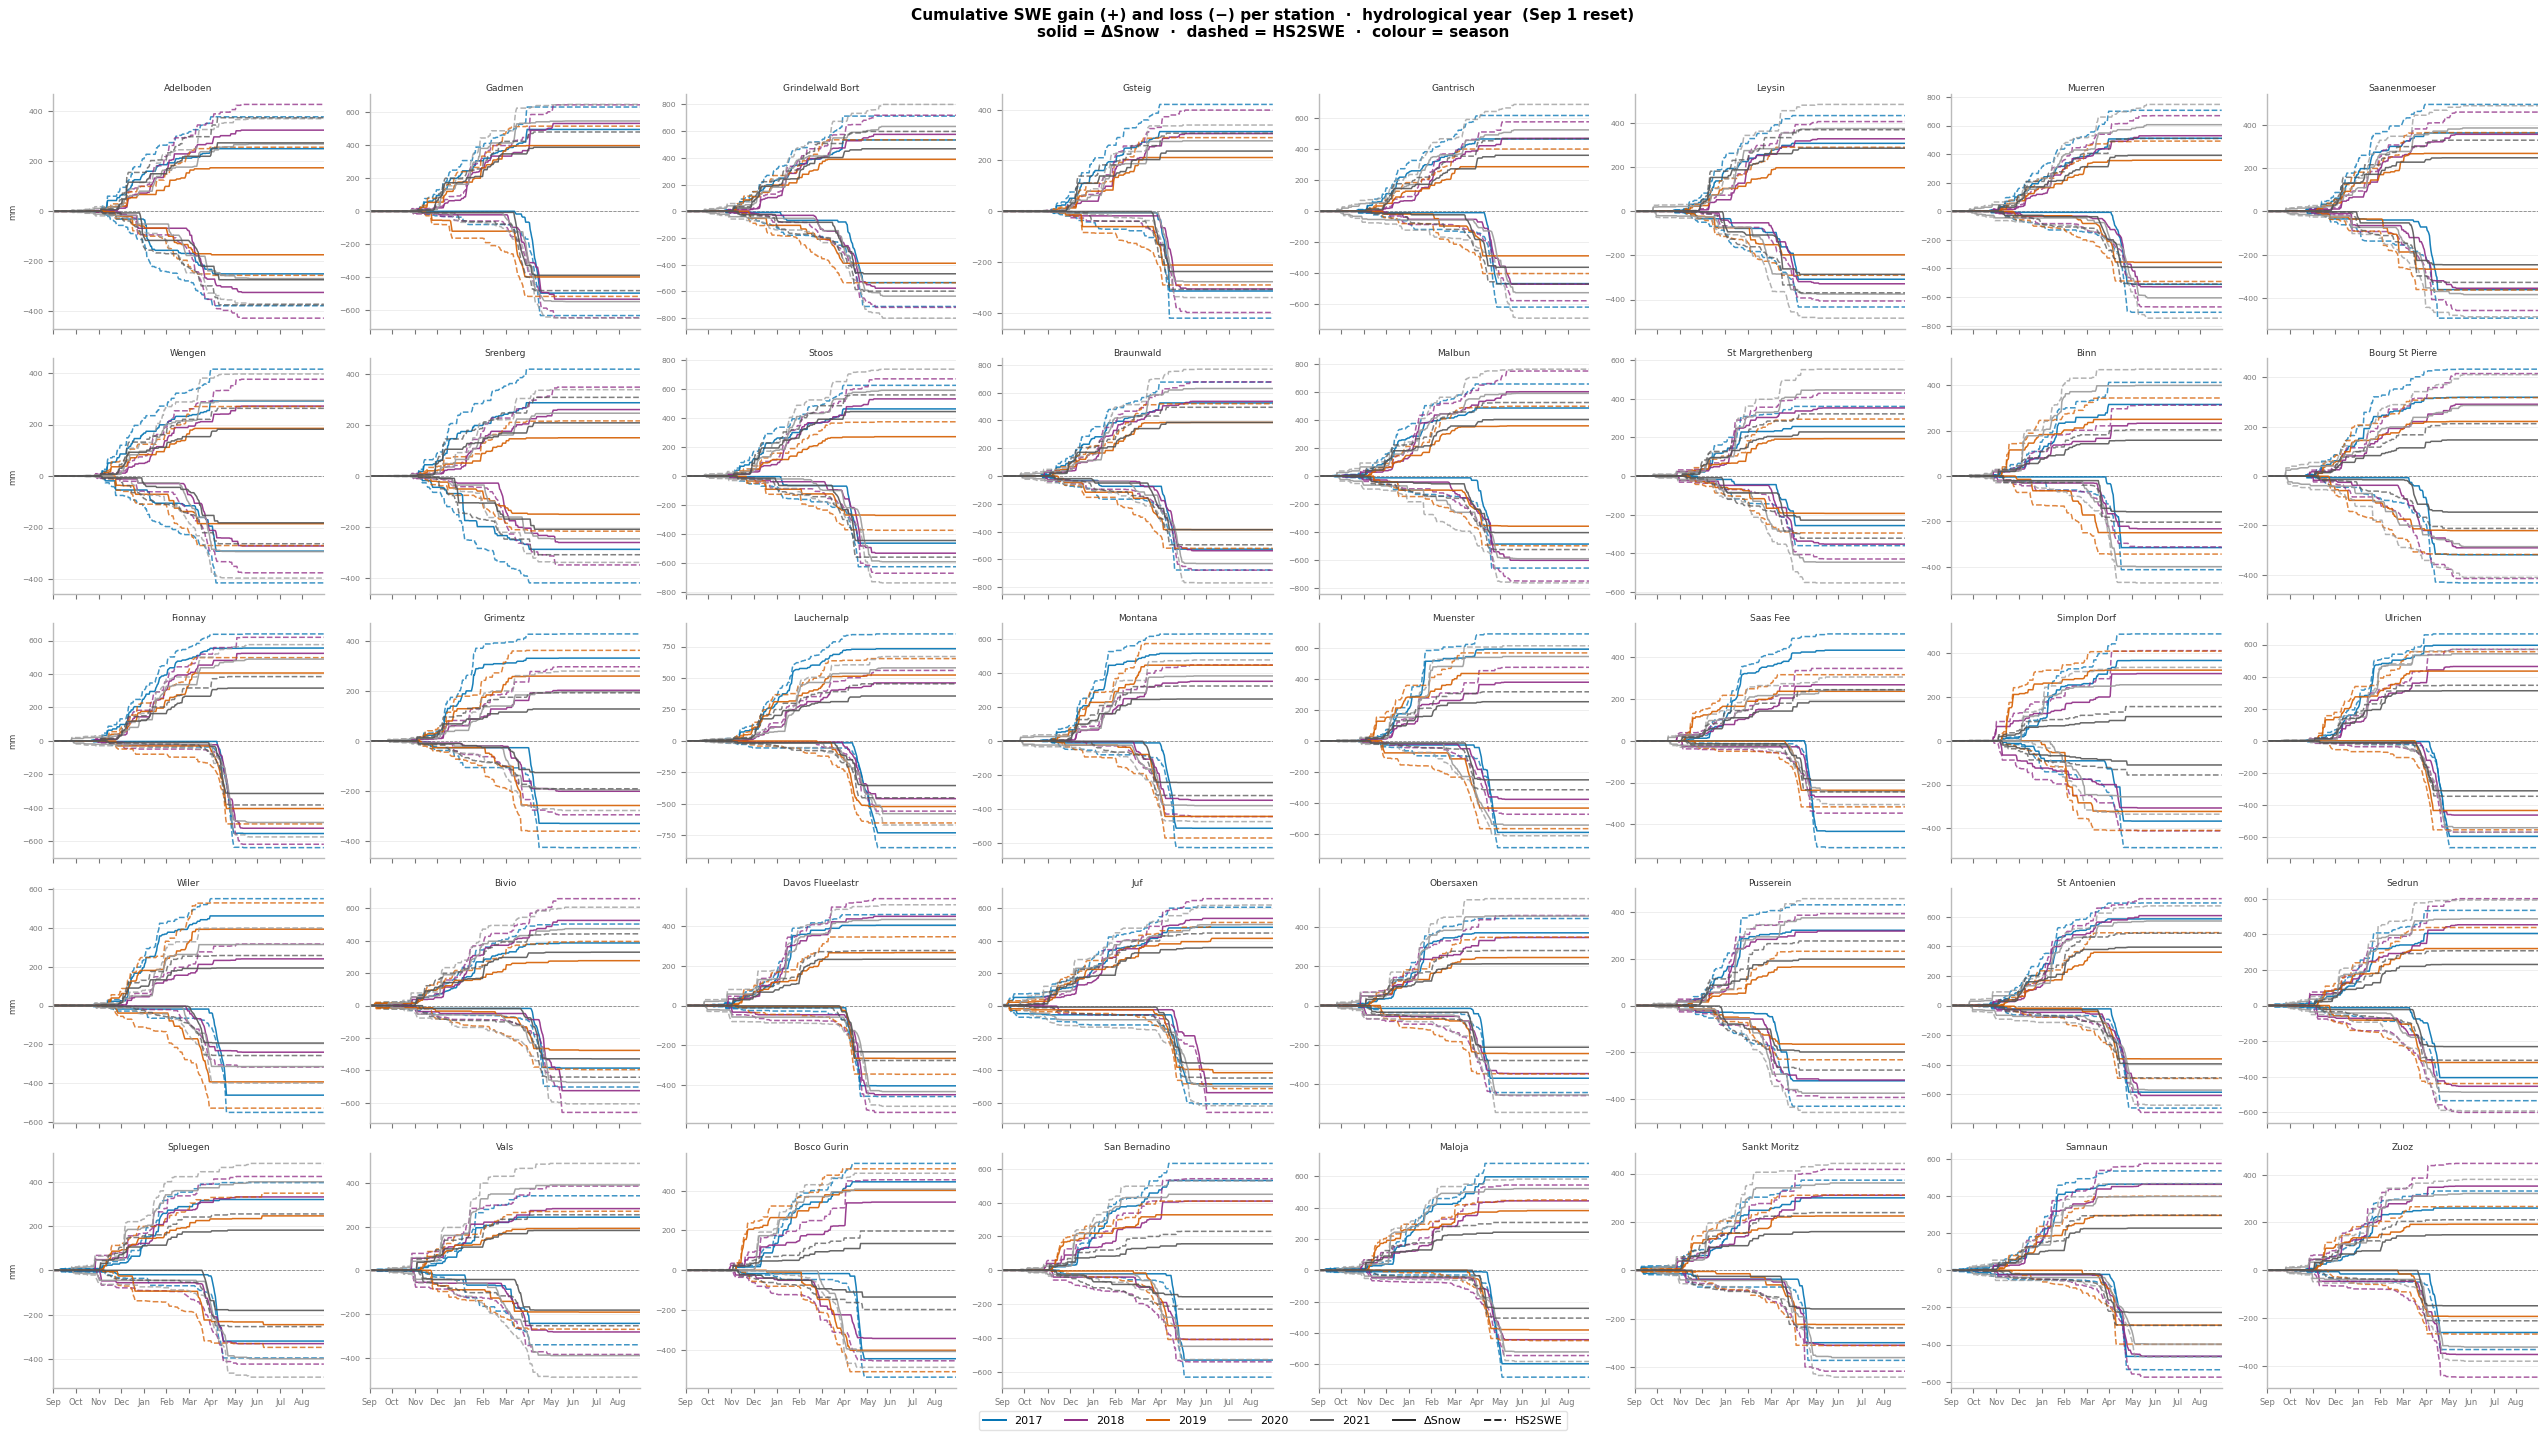

In [17]:
# ── Plot 2: station grid 8×5 — cumulative SWE gain / loss, hydrological year ──
NCOLS, NROWS = 8, 5

fig, axes = plt.subplots(NROWS, NCOLS,
                          figsize=(NCOLS * 3.2, NROWS * 2.8),
                          sharex=True, sharey=False)
fig.suptitle(
    "Cumulative SWE gain (+) and loss (−) per station  ·  hydrological year  (Sep 1 reset)\n"
    "solid = ΔSnow  ·  dashed = HS2SWE  ·  colour = season",
    fontsize=11, y=1.01,
)

for si, ax in enumerate(axes.flat):
    if si >= len(stn):
        ax.set_visible(False)
        continue
    ax.axhline(0, color=C.OBS, lw=0.6, ls="--", alpha=0.5)
    for yi, yr in enumerate(CAL_YEARS):
        col = YR_COLORS[yi]
        ax.plot(doy_ax, d_cg[yi, :, si], color=col, lw=1.1, alpha=0.9,  ls=LS.SWE)
        ax.plot(doy_ax, d_cl[yi, :, si], color=col, lw=1.1, alpha=0.9,  ls=LS.SWE)
        ax.plot(doy_ax, h_cg[yi, :, si], color=col, lw=1.1, alpha=0.75, ls=LS.HS)
        ax.plot(doy_ax, h_cl[yi, :, si], color=col, lw=1.1, alpha=0.75, ls=LS.HS)
    ax.set_title(stn[si].replace("_", " "), fontsize=6.5, pad=2)
    ax.tick_params(labelsize=5.5)
    ax.spines[["top", "right"]].set_visible(False)
    if si % NCOLS == 0:
        ax.set_ylabel("mm", fontsize=6)

for ax in axes[-1]:
    ax.set_xticks(MONTH_TICKS)
    ax.set_xticklabels(MONTH_LABELS, fontsize=6)
    ax.set_xlim(1, N_DOYS)

yr_handles = [mlines.Line2D([], [], color=YR_COLORS[i], lw=1.4,
                             label=str(yr)) for i, yr in enumerate(CAL_YEARS)]
model_handles = [
    mlines.Line2D([], [], color=C.OBS, lw=1.4, ls=LS.SWE, label="ΔSnow"),
    mlines.Line2D([], [], color=C.OBS, lw=1.4, ls=LS.HS,  label="HS2SWE"),
]
fig.legend(handles=yr_handles + model_handles,
           ncol=len(CAL_YEARS) + 2, loc="lower center",
           bbox_to_anchor=(0.5, -0.01), fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "station_grid_gain_loss_hydro.png", **FIG.SAVE)
plt.show()


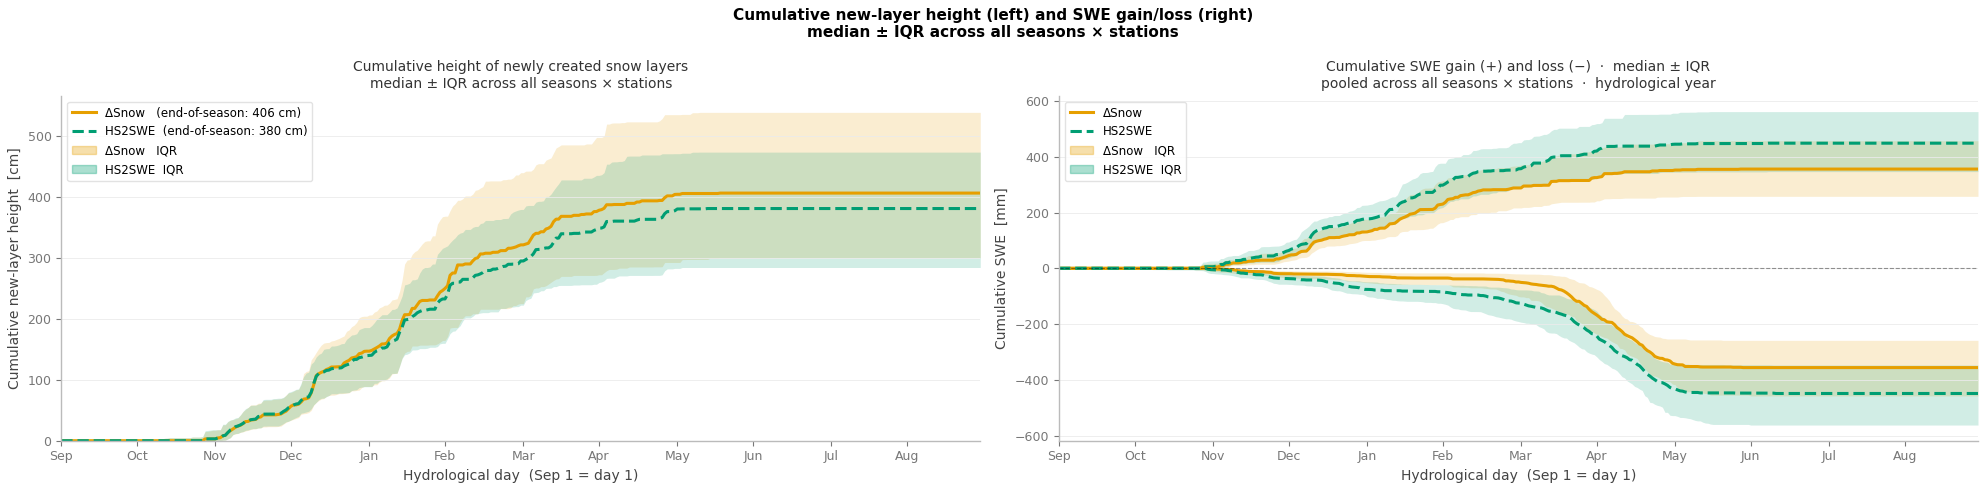

In [18]:
# ── Plot 1: cumulative new-layer height (left) + SWE gain/loss (right) ────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(FIG.SINGLE[0] * 2, FIG.SINGLE[1]))

# Left: new-layer height
ax_l.fill_between(doy_ax, ds_q25 * 100, ds_q75 * 100, color=C.DSNOW,  alpha=ALPHA.BAND, lw=0)
ax_l.fill_between(doy_ax, h2_q25 * 100, h2_q75 * 100, color=C.HS2SWE, alpha=ALPHA.BAND, lw=0)
ax_l.plot(doy_ax, ds_med * 100, color=C.DSNOW,  lw=2.2, ls=LS.SWE,
          label=f"ΔSnow   (end-of-season: {ds_med[-1]*100:.0f} cm)")
ax_l.plot(doy_ax, h2_med * 100, color=C.HS2SWE, lw=2.2, ls=LS.HS,
          label=f"HS2SWE  (end-of-season: {h2_med[-1]*100:.0f} cm)")
ax_l.fill_between([], [], [], color=C.DSNOW,  alpha=ALPHA.BAND + 0.15, label="ΔSnow   IQR")
ax_l.fill_between([], [], [], color=C.HS2SWE, alpha=ALPHA.BAND + 0.15, label="HS2SWE  IQR")
ax_l.set_ylim(bottom=0)
ax_l.set_ylabel("Cumulative new-layer height  [cm]")
ax_l.set_title("Cumulative height of newly created snow layers\nmedian ± IQR across all seasons × stations",
               fontsize=10)
ax_l.legend(fontsize=8.5)
ax_l.spines[["top", "right"]].set_visible(False)

# Right: SWE gain / loss
ax_r.fill_between(doy_ax, d_cg_q25, d_cg_q75, color=C.DSNOW,  alpha=ALPHA.BAND, lw=0)
ax_r.fill_between(doy_ax, h_cg_q25, h_cg_q75, color=C.HS2SWE, alpha=ALPHA.BAND, lw=0)
ax_r.fill_between(doy_ax, d_cl_q25, d_cl_q75, color=C.DSNOW,  alpha=ALPHA.BAND, lw=0)
ax_r.fill_between(doy_ax, h_cl_q25, h_cl_q75, color=C.HS2SWE, alpha=ALPHA.BAND, lw=0)
ax_r.plot(doy_ax, d_cg_med, color=C.DSNOW,  lw=2.2, ls=LS.SWE, label="ΔSnow")
ax_r.plot(doy_ax, h_cg_med, color=C.HS2SWE, lw=2.2, ls=LS.HS,  label="HS2SWE")
ax_r.plot(doy_ax, d_cl_med, color=C.DSNOW,  lw=2.2, ls=LS.SWE)
ax_r.plot(doy_ax, h_cl_med, color=C.HS2SWE, lw=2.2, ls=LS.HS)
ax_r.fill_between([], [], [], color=C.DSNOW,  alpha=ALPHA.BAND + 0.15, label="ΔSnow   IQR")
ax_r.fill_between([], [], [], color=C.HS2SWE, alpha=ALPHA.BAND + 0.15, label="HS2SWE  IQR")
ax_r.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
ax_r.set_ylabel("Cumulative SWE  [mm]")
ax_r.set_title("Cumulative SWE gain (+) and loss (−)  ·  median ± IQR\n"
               "pooled across all seasons × stations  ·  hydrological year", fontsize=10)
ax_r.legend(fontsize=8.5)
ax_r.spines[["top", "right"]].set_visible(False)

for ax in (ax_l, ax_r):
    ax.set_xticks(MONTH_TICKS)
    ax.set_xticklabels(MONTH_LABELS)
    ax.set_xlim(1, N_DOYS)
    ax.set_xlabel("Hydrological day  (Sep 1 = day 1)")

fig.suptitle("Cumulative new-layer height (left) and SWE gain/loss (right)\n"
             "median ± IQR across all seasons × stations",
             fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "cumulative_combined.png", **FIG.SAVE)
plt.show()
